# Confusion Matrix in Python

## 1. Libraries and setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "grid.alpha": 0.25,
})

## 2. Helper functions


In [2]:
def plot_confusion_matrix_table(y_true, y_pred, labels, title="Confusion matrix"):
    """Plot a confusion matrix with actual classes on rows and predicted classes on columns."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels],
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.ylabel("Actual class")
    plt.xlabel("Predicted class")
    plt.tight_layout()
    plt.show()

    return cm_df


def binary_metrics_table(y_true, y_pred, positive_label=1):
    """Return the most common binary-classification metrics in one table."""
    return pd.DataFrame({
        "metric": ["accuracy", "precision", "recall / sensitivity", "F1-score"],
        "value": [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
            recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
            f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        ],
    }).round(3)


def predict_with_threshold(probabilities, threshold=0.50):
    """Convert predicted probabilities into class predictions."""
    return (probabilities >= threshold).astype(int)

## 3. Simple example: actual labels versus predicted labels

A confusion matrix compares what actually happened with what the model predicted. Before using a model, start with known labels so the logic is visible.

In [3]:
actual = np.array(["Dog", "Dog", "Dog", "Not Dog", "Dog", "Not Dog", "Dog", "Dog", "Not Dog", "Not Dog"])
predicted = np.array(["Dog", "Not Dog", "Dog", "Not Dog", "Dog", "Dog", "Dog", "Dog", "Not Dog", "Not Dog"])

simple_results = pd.DataFrame({"actual": actual, "predicted": predicted})
simple_results["result"] = np.where(simple_results["actual"] == simple_results["predicted"], "correct", "wrong")
simple_results

,actual,predicted,result
0,Dog,Dog,correct
1,Dog,Not Dog,wrong
2,Dog,Dog,correct
3,Not Dog,Not Dog,correct
4,Dog,Dog,correct
5,Not Dog,Dog,wrong
6,Dog,Dog,correct
7,Dog,Dog,correct
8,Not Dog,Not Dog,correct
9,Not Dog,Not Dog,correct


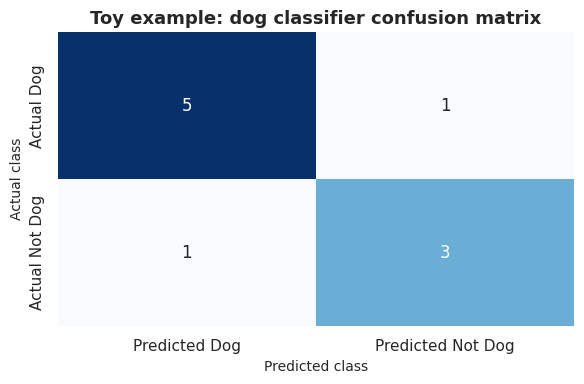

,Predicted Dog,Predicted Not Dog
Actual Dog,5,1
Actual Not Dog,1,3


In [4]:
cm_dog = plot_confusion_matrix_table(
    actual,
    predicted,
    labels=["Dog", "Not Dog"],
    title="Toy example: dog classifier confusion matrix"
)
cm_dog

**Interpretation.** The diagonal cells are correct predictions. The off-diagonal cells are mistakes. Always check the matrix orientation: in this notebook, rows are actual classes and columns are predicted classes.

## 4. Binary confusion matrix from scratch

For binary classification, define the positive class first. In this example, `Dog` is the positive class. The meaning of TP, FP, FN, and TN depends on this definition.

In [5]:
positive_class = "Dog"

TP = np.sum((actual == positive_class) & (predicted == positive_class))
FN = np.sum((actual == positive_class) & (predicted != positive_class))
FP = np.sum((actual != positive_class) & (predicted == positive_class))
TN = np.sum((actual != positive_class) & (predicted != positive_class))

manual_cm = pd.DataFrame(
    [[TP, FN], [FP, TN]],
    index=["Actual positive", "Actual negative"],
    columns=["Predicted positive", "Predicted negative"],
)
manual_cm

,Predicted positive,Predicted negative
Actual positive,5,1
Actual negative,1,3


In [7]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

type_1_error_rate = FP / (FP + TN)   # False positive rate
ntype_2_error_rate = FN / (TP + FN)   # False negative rate

pd.DataFrame({
    "metric": ["accuracy", "precision", "recall / sensitivity", "specificity", "F1-score", "Type I error rate", "Type II error rate"],
    "value": [accuracy, precision, recall, specificity, f1, type_1_error_rate, ntype_2_error_rate],
}).round(3)

,metric,value
0,accuracy,0.800
1,precision,0.833
2,recall / sensitivity,0.833
3,specificity,0.750
4,F1-score,0.833
5,Type I error rate,0.250
6,Type II error rate,0.167


**Interpretation.**
* Accuracy summarizes all correct predictions.
* Precision asks: “When the model predicts positive, how often is it right?”
* Recall asks: “Of all actual positives, how many did the model find?”
* Specificity asks the same question for actual negatives.

## 5. Why accuracy can be misleading with imbalanced data

In many business problems, the important class is rare: faulty products, fraud cases, customer churn, machine failure, or medical risk. A model can have high accuracy while missing most of the important class.

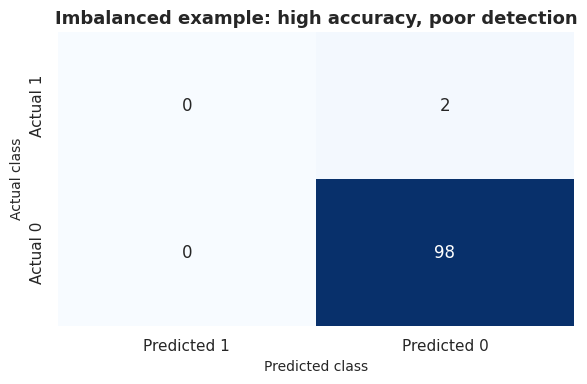

,metric,value
0,accuracy,0.98
1,precision,0.00
2,recall / sensitivity,0.00
3,F1-score,0.00


In [8]:
# 98 good items and 2 faulty items
quality_df = pd.DataFrame({
    "actual_faulty": np.r_[np.zeros(98, dtype=int), np.ones(2, dtype=int)]
})

# A naive model predicts every item as good / not faulty.
quality_df["predicted_faulty"] = 0

plot_confusion_matrix_table(
    quality_df["actual_faulty"],
    quality_df["predicted_faulty"],
    labels=[1, 0],
    title="Imbalanced example: high accuracy, poor detection"
)

binary_metrics_table(quality_df["actual_faulty"], quality_df["predicted_faulty"], positive_label=1)

**Interpretation.** Accuracy is high because almost all items are good. However, recall for the faulty class is zero: the model did not identify any faulty item. In a quality-control case, this may be unacceptable even if the accuracy looks excellent.

## 6. Build a realistic binary classifier

Now we train a logistic regression model on the built-in breast cancer dataset. The positive class is defined as `1 = malignant risk` so that the confusion matrix focuses on detecting risk.

In [9]:
cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()

# Original target: 0 = malignant, 1 = benign.
# Recode to make 1 the risk class: 1 = malignant, 0 = benign.
cancer_df["malignant_risk"] = (cancer_df["target"] == 0).astype(int)
cancer_df = cancer_df.drop(columns="target")

print("Shape:", cancer_df.shape)
cancer_df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant_risk
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


malignant_risk
benign / low risk    357
malignant risk       212
Name: count, dtype: int64


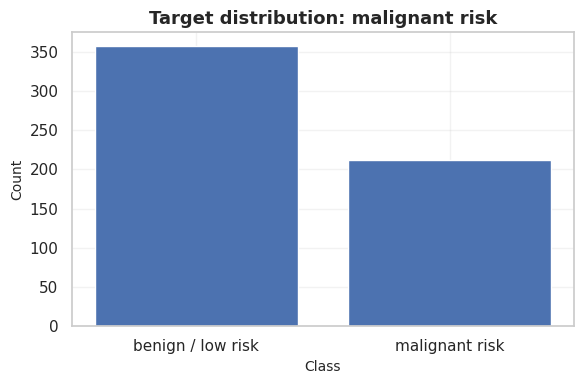

In [10]:
target_balance = cancer_df["malignant_risk"].value_counts().sort_index().rename(index={0: "benign / low risk", 1: "malignant risk"})
print(target_balance)

plt.figure(figsize=(6, 4))
plt.bar(target_balance.index.astype(str), target_balance.values)
plt.title("Target distribution: malignant risk")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

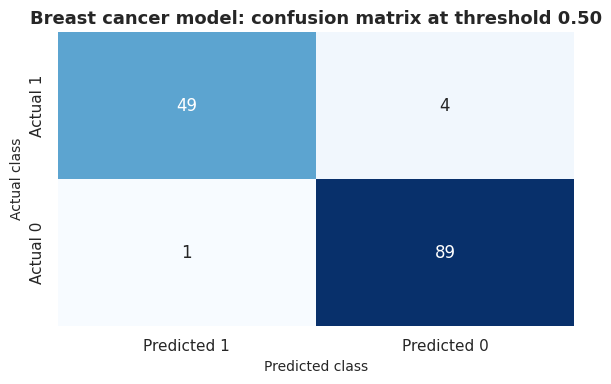

,metric,value
0,accuracy,0.965
1,precision,0.980
2,recall / sensitivity,0.925
3,F1-score,0.951


In [11]:
X = cancer_df.drop(columns="malignant_risk")
y = cancer_df["malignant_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)
y_pred_default = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

plot_confusion_matrix_table(
    y_test,
    y_pred_default,
    labels=[1, 0],
    title="Breast cancer model: confusion matrix at threshold 0.50"
)

binary_metrics_table(y_test, y_pred_default, positive_label=1)

In [12]:
print(classification_report(
    y_test,
    y_pred_default,
    target_names=["benign / low risk", "malignant risk"],
    zero_division=0,
))

                   precision    recall  f1-score   support

benign / low risk       0.96      0.99      0.97        90
   malignant risk       0.98      0.92      0.95        53

         accuracy                           0.97       143
        macro avg       0.97      0.96      0.96       143
     weighted avg       0.97      0.97      0.96       143



**Interpretation.** The classification report separates performance by class. For high-risk cases, recall is often especially important because a false negative means a risk case was missed.

## 7. Threshold tuning: changing the decision rule

Many classifiers first estimate a probability. A threshold converts the probability into a class. The default threshold is often 0.50, but this is not automatically the best business decision.

In [13]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_rows = []

for threshold in thresholds:
    y_pred_threshold = predict_with_threshold(y_proba, threshold)
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_threshold),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "false_positives": confusion_matrix(y_test, y_pred_threshold, labels=[1, 0])[1, 0],
        "false_negatives": confusion_matrix(y_test, y_pred_threshold, labels=[1, 0])[0, 1],
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results.head()

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives
0,0.10,0.951049,0.896552,0.981132,0.936937,6,1
1,0.15,0.965035,0.928571,0.981132,0.954128,4,1
2,0.20,0.965035,0.944444,0.962264,0.953271,3,2
3,0.25,0.972028,0.962264,0.962264,0.962264,2,2
4,0.30,0.979021,0.980769,0.962264,0.971429,1,2


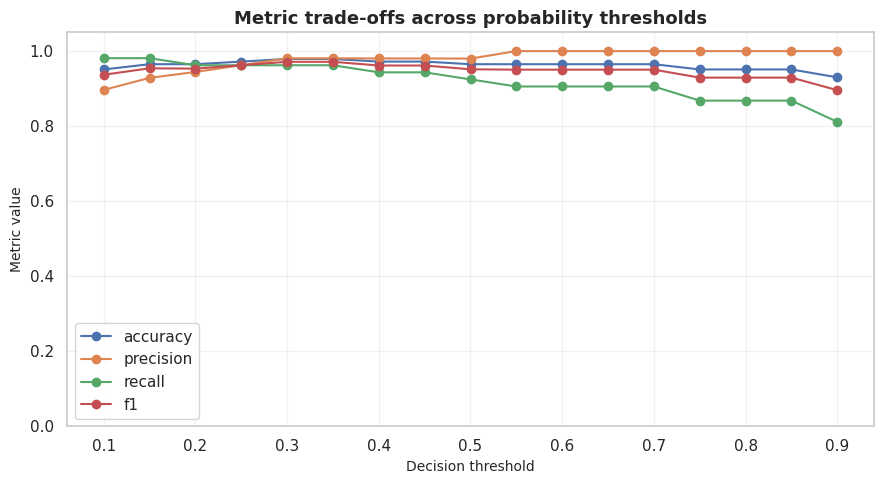

In [14]:
plt.figure(figsize=(9, 5))
for metric in ["accuracy", "precision", "recall", "f1"]:
    plt.plot(threshold_results["threshold"], threshold_results[metric], marker="o", label=metric)

plt.title("Metric trade-offs across probability thresholds")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

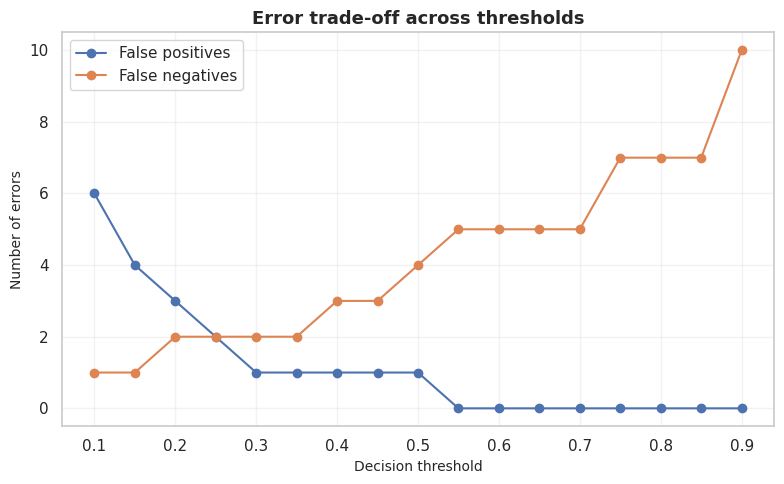

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives
4,0.30,0.979,0.981,0.962,0.971,1,2
5,0.35,0.979,0.981,0.962,0.971,1,2
3,0.25,0.972,0.962,0.962,0.962,2,2
7,0.45,0.972,0.980,0.943,0.962,1,3
6,0.40,0.972,0.980,0.943,0.962,1,3
1,0.15,0.965,0.929,0.981,0.954,4,1
2,0.20,0.965,0.944,0.962,0.953,3,2
8,0.50,0.965,0.980,0.925,0.951,1,4
9,0.55,0.965,1.000,0.906,0.950,0,5
11,0.65,0.965,1.000,0.906,0.950,0,5


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results["threshold"], threshold_results["false_positives"], marker="o", label="False positives")
plt.plot(threshold_results["threshold"], threshold_results["false_negatives"], marker="o", label="False negatives")
plt.title("Error trade-off across thresholds")
plt.xlabel("Decision threshold")
plt.ylabel("Number of errors")
plt.legend()
plt.tight_layout()
plt.show()

threshold_results.sort_values("f1", ascending=False).head(10).round(3)

**Interpretation.** Lowering the threshold usually increases recall but may create more false positives. Raising the threshold usually improves precision but may miss more positives. The right threshold depends on which error is more expensive.

## 8. Select a threshold based on business cost

A practical decision rule can assign a cost to each error type. The example below assumes a false negative is more costly than a false positive.

In [16]:
COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 8

cost_results = threshold_results.copy()
cost_results["estimated_error_cost"] = (
    cost_results["false_positives"] * COST_FALSE_POSITIVE
    + cost_results["false_negatives"] * COST_FALSE_NEGATIVE
)

best_cost_row = cost_results.sort_values("estimated_error_cost").iloc[0]
best_threshold = best_cost_row["threshold"]

print("Best threshold based on the assumed cost logic:", round(best_threshold, 2))
cost_results.sort_values("estimated_error_cost").head(10).round(3)

Best threshold based on the assumed cost logic: 0.15


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,estimated_error_cost
1,0.15,0.965,0.929,0.981,0.954,4,1,12
0,0.10,0.951,0.897,0.981,0.937,6,1,14
5,0.35,0.979,0.981,0.962,0.971,1,2,17
4,0.30,0.979,0.981,0.962,0.971,1,2,17
3,0.25,0.972,0.962,0.962,0.962,2,2,18
2,0.20,0.965,0.944,0.962,0.953,3,2,19
6,0.40,0.972,0.980,0.943,0.962,1,3,25
7,0.45,0.972,0.980,0.943,0.962,1,3,25
8,0.50,0.965,0.980,0.925,0.951,1,4,33
9,0.55,0.965,1.000,0.906,0.950,0,5,40


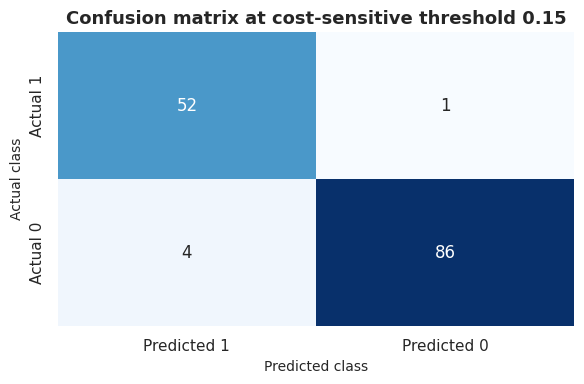

,metric,value
0,accuracy,0.965
1,precision,0.929
2,recall / sensitivity,0.981
3,F1-score,0.954


In [17]:
y_pred_cost = predict_with_threshold(y_proba, best_threshold)

plot_confusion_matrix_table(
    y_test,
    y_pred_cost,
    labels=[1, 0],
    title=f"Confusion matrix at cost-sensitive threshold {best_threshold:.2f}"
)

binary_metrics_table(y_test, y_pred_cost, positive_label=1)

**Interpretation.** This threshold is not “mathematically correct” by itself; it is correct only under the assumed cost logic. In business settings, the cost of false positives and false negatives should be discussed before selecting the final decision threshold.

## 9. ROC curve and AUC

The ROC curve evaluates the model across many thresholds. It compares the true positive rate with the false positive rate. AUC summarizes how well the model ranks positive cases above negative cases.

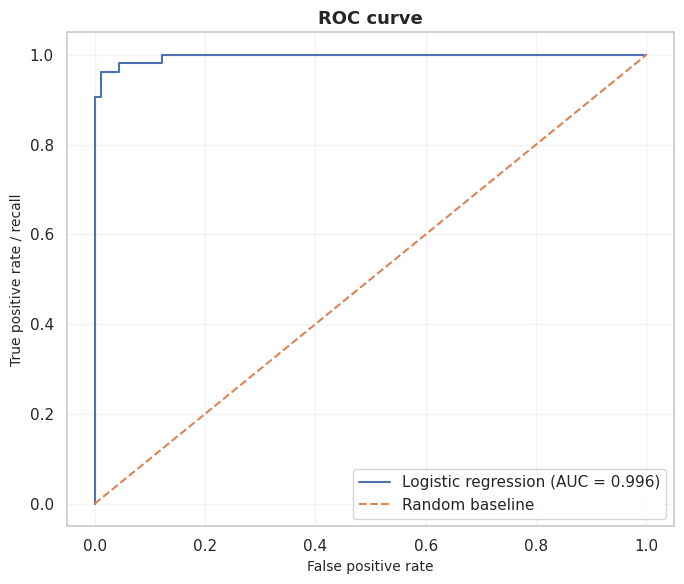

In [18]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.title("ROC curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / recall")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation.** AUC near 1 indicates strong separation between the classes. AUC near 0.5 indicates performance close to random ranking. ROC AUC is useful, but it can look optimistic when the positive class is very rare.

## 10. Precision-recall curve and average precision

The precision-recall curve focuses directly on the positive class. It is especially useful when the positive class is rare or when false positives and false negatives have different business implications.

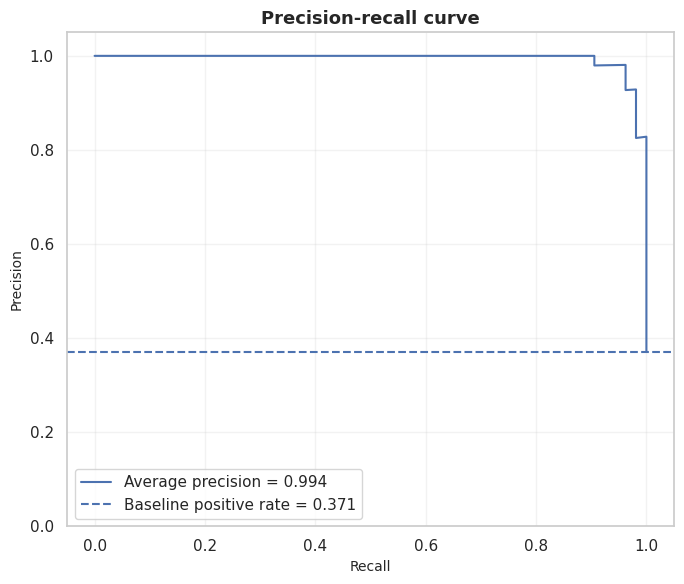

In [19]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)
baseline_precision = y_test.mean()

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"Average precision = {average_precision:.3f}")
plt.axhline(baseline_precision, linestyle="--", label=f"Baseline positive rate = {baseline_precision:.3f}")
plt.title("Precision-recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation.** A strong model keeps precision high while recall increases. The baseline is the share of positive cases. For rare-event detection, this view is often more informative than accuracy alone.

## 11. Compare two models with the same evaluation logic

The confusion matrix is model-independent. The same metrics can evaluate logistic regression, random forest, or any other classifier.

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = predict_with_threshold(rf_proba, 0.50)

comparison = pd.concat([
    binary_metrics_table(y_test, y_pred_default, positive_label=1).assign(model="Logistic regression"),
    binary_metrics_table(y_test, rf_pred, positive_label=1).assign(model="Random forest"),
])

comparison.pivot(index="metric", columns="model", values="value")

model,Logistic regression,Random forest
metric,,
F1-score,0.951,0.961
accuracy,0.965,0.972
precision,0.980,1.000
recall / sensitivity,0.925,0.925


In [21]:
model_auc = pd.DataFrame({
    "model": ["Logistic regression", "Random forest"],
    "ROC AUC": [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, rf_proba)],
    "Average precision": [average_precision_score(y_test, y_proba), average_precision_score(y_test, rf_proba)],
}).round(3)
model_auc

,model,ROC AUC,Average precision
0,Logistic regression,0.996,0.994
1,Random forest,0.998,0.997


**Interpretation.** Compare models with the same test set and the same positive-class definition. A model with the highest AUC is not automatically the best operational choice if its confusion matrix creates unacceptable error costs at the selected threshold.

## 12. Synthetic manufacturing-quality dataset

This section mirrors a common industrial data-mining case: the target class is rare, but it is the class the business cares about.

In [22]:
X_synth, y_synth = make_classification(
    n_samples=1200,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    weights=[0.92, 0.08],
    class_sep=1.2,
    flip_y=0.02,
    random_state=RANDOM_STATE,
)

synth_columns = [
    "sensor_temperature",
    "sensor_pressure",
    "sensor_vibration",
    "sensor_voltage",
    "process_speed",
    "material_density",
]

synth_df = pd.DataFrame(X_synth, columns=synth_columns)
synth_df["faulty"] = y_synth
synth_df.head()

,sensor_temperature,sensor_pressure,sensor_vibration,sensor_voltage,process_speed,material_density,faulty
0,-3.510106,4.475032,-0.664697,-9.849601,-0.506035,-3.480779,0
1,-0.483497,-1.369504,0.207565,1.985393,-0.447813,1.289699,0
2,0.793992,-0.928765,-3.926672,-0.700724,1.207822,-2.170759,0
3,-1.553691,2.628005,2.046873,-5.410377,-0.771409,-2.523921,0
4,-1.252924,-1.262622,-1.205928,-0.926038,-1.014636,-1.339336,0


faulty
good      1089
faulty     111
Name: count, dtype: int64


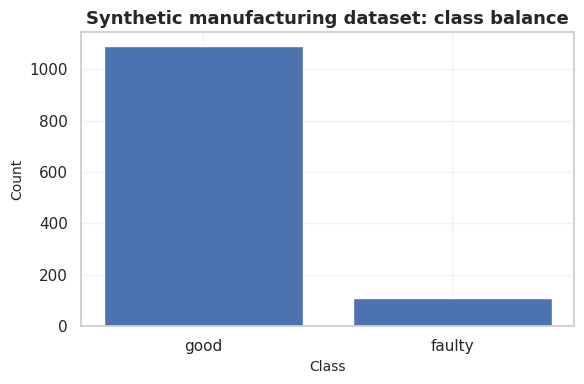

In [23]:
faulty_balance = synth_df["faulty"].value_counts().sort_index().rename(index={0: "good", 1: "faulty"})
print(faulty_balance)

plt.figure(figsize=(6, 4))
plt.bar(faulty_balance.index.astype(str), faulty_balance.values)
plt.title("Synthetic manufacturing dataset: class balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

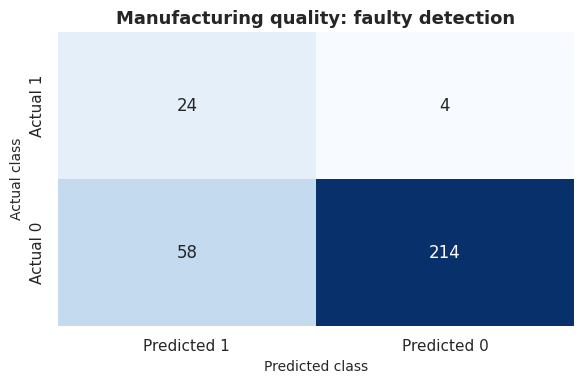

,metric,value
0,accuracy,0.793
1,precision,0.293
2,recall / sensitivity,0.857
3,F1-score,0.436


In [24]:
X = synth_df.drop(columns="faulty")
y = synth_df["faulty"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

synth_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

synth_model.fit(X_train_s, y_train_s)
synth_proba = synth_model.predict_proba(X_test_s)[:, 1]
synth_pred = predict_with_threshold(synth_proba, 0.50)

plot_confusion_matrix_table(y_test_s, synth_pred, labels=[1, 0], title="Manufacturing quality: faulty detection")
binary_metrics_table(y_test_s, synth_pred, positive_label=1)

**Interpretation.** For manufacturing quality, the relevant question is often not “How many total items did we classify correctly?” but “How many faulty items did we catch, and how many good items did we unnecessarily block?”

## 13. Multiclass example: Iris classification

A confusion matrix also works for more than two classes. The main difference is that TP, FP, FN, and TN become class-specific concepts rather than one simple 2 × 2 table.

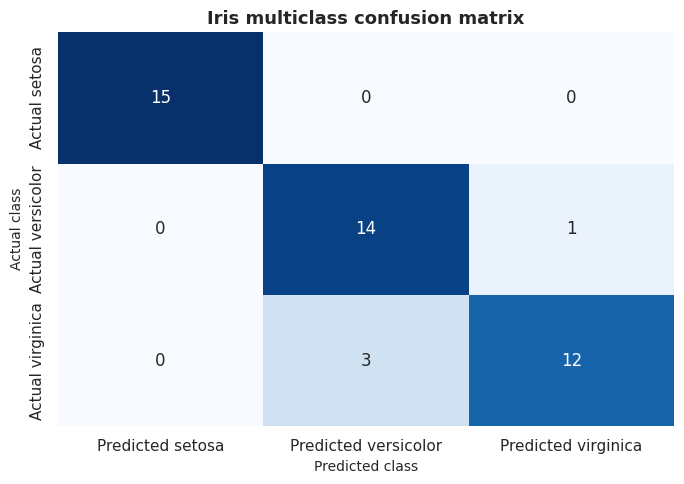

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [25]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()

X_iris = iris_df.drop(columns="target")
y_iris = iris_df["target"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris,
    y_iris,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_iris,
)

iris_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
iris_model.fit(X_train_i, y_train_i)
y_pred_i = iris_model.predict(X_test_i)

iris_labels = list(range(3))
iris_label_names = iris.target_names

cm_iris = confusion_matrix(y_test_i, y_pred_i, labels=iris_labels)
cm_iris_df = pd.DataFrame(
    cm_iris,
    index=[f"Actual {name}" for name in iris_label_names],
    columns=[f"Predicted {name}" for name in iris_label_names],
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_iris_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Iris multiclass confusion matrix")
plt.ylabel("Actual class")
plt.xlabel("Predicted class")
plt.tight_layout()
plt.show()

print(classification_report(y_test_i, y_pred_i, target_names=iris_label_names))

**Interpretation.** In multiclass classification, inspect which classes are confused with each other. This is often more useful than looking only at the overall accuracy.

## Common mistakes and practical pitfalls

- **Confusing matrix orientation:** always check whether rows or columns represent actual values.
- **Forgetting the positive class definition:** metrics such as precision and recall depend on which class is treated as positive.
- **Relying only on accuracy:** high accuracy can hide poor detection of a rare but important class.
- **Ignoring threshold effects:** the default 0.50 threshold may not match the business cost of mistakes.
- **Trying to minimize all errors at once:** reducing false positives can increase false negatives, and vice versa.
- **Comparing models on different test sets:** use the same split and same target definition for fair comparison.
- **Treating AUC as an operational decision:** AUC evaluates ranking across thresholds, but deployment still requires a threshold.